## Exploratory Data Analysis

### Packages

In [2]:
# Data handling
import pandas as pd
import geopandas as gpd

#required import for geopandas (as we are using it), that was not auto installed as a dependency
import pyarrow

# Data reading
import requests
from io import BytesIO, StringIO

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import leafmap.foliumap as leafmap


### Read the Clean Datasets

In [3]:
# Read the OD flows parquet file into a GeoDataFrame
url_flows = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_destination_flows_CLEAN.parquet"
r_flows = requests.get(url_flows)
od_flows = gpd.read_parquet(BytesIO(r_flows.content))

# Read the origin time series file into a DataFrame
url_ts = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_ridership_time_series_CLEAN.csv"
origin = pd.read_csv(StringIO(requests.get(url_ts, verify=False).text))

### Displaying the Clean Datasets

In [4]:
display(od_flows.head())
display(origin.head())

,origin_station_complex_name,destination_station_complex_name,origin_station_complex_id,destination_station_complex_id,sum_estimated_average_ridership,geometry,distance_meters,distance_km,log_ridership,riders_per_km,origin_point_wkt,destination_point_wkt
0,Beach 44 St (A),Grand St (L),206,123,30.2032,"LINESTRING (-73.77601 40.59294, -73.94067 40.7...",19191.098843,19.191099,3.440521,1.573813,POINT (-73.776013 40.592943),POINT (-73.94067 40.711926)
1,57 St (F),"Astoria Blvd (N,W)",224,2,595.8536,"LINESTRING (-73.97745 40.76397, -73.91784 40.7...",5079.298729,5.079299,6.391672,117.310210,POINT (-73.97745 40.763972),POINT (-73.917843 40.770258)
2,Rector St (1),Buhre Av (6),329,361,8.8919,"LINESTRING (-74.01378 40.70751, -73.83257 40.8...",21749.099473,21.749099,2.291716,0.408840,POINT (-74.013783 40.707513),POINT (-73.832569 40.84681)
3,"30 Av (N,W)","Simpson St (2,5)",3,430,222.4353,"LINESTRING (-73.92148 40.76678, -73.89306 40.8...",6797.412960,6.797413,5.409122,32.723523,POINT (-73.921479 40.766779),POINT (-73.893064 40.824073)
4,"Northern Blvd (M,R)",2 Av (F),269,232,1036.2171,"LINESTRING (-73.90601 40.75288, -73.98994 40.7...",7806.638810,7.806639,6.944297,132.735371,POINT (-73.906006 40.752885),POINT (-73.989938 40.723402)


,month,day_of_week,hour_of_day,origin_station_complex_id,origin_station_complex_name,origin_latitude,origin_longitude,origin_point,sum_estimated_average_ridership
0,1,Friday,0,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),35.7473
1,1,Friday,1,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),11.4975
2,1,Friday,2,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),10.9980
3,1,Friday,3,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),14.7534
4,1,Friday,4,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),52.0023


## Descriptive Statistics

In [5]:
origin[origin['day_of_week'] == 'Friday']['sum_estimated_average_ridership'].sum()

np.float64(42555436.7229)

## Distributions

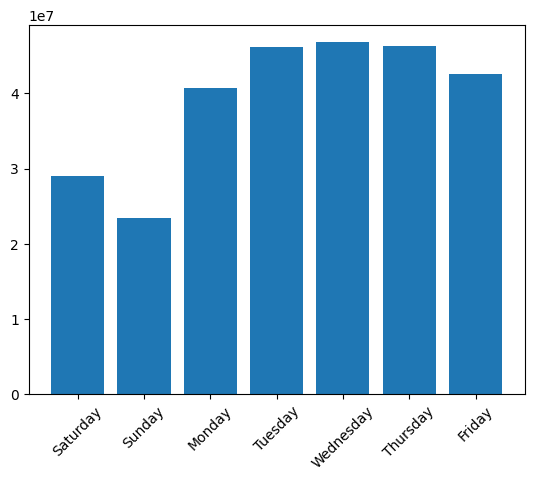

Day of the week: total ridership
Saturday: 29009734.824400004
Sunday: 23397423.0419
Monday: 40750677.3636
Tuesday: 46106946.11710001
Wednesday: 46749949.3101
Thursday: 46325195.7268
Friday: 42555436.7229


In [6]:
# origin day of week
day_of_week = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
total_ridership_per_day_of_week = [origin[origin['day_of_week'] == i]['sum_estimated_average_ridership'].sum() for i in day_of_week]
plt.bar(day_of_week, total_ridership_per_day_of_week)
plt.tick_params(axis='x', labelrotation=45)
# plt.ticklabel_format(style='plain') #for some reason this is only causing an error for this graph
plt.show()
print('Day of the week: total ridership')
for i in range(7):
    print(f'{day_of_week[i]}: {total_ridership_per_day_of_week[i]}')

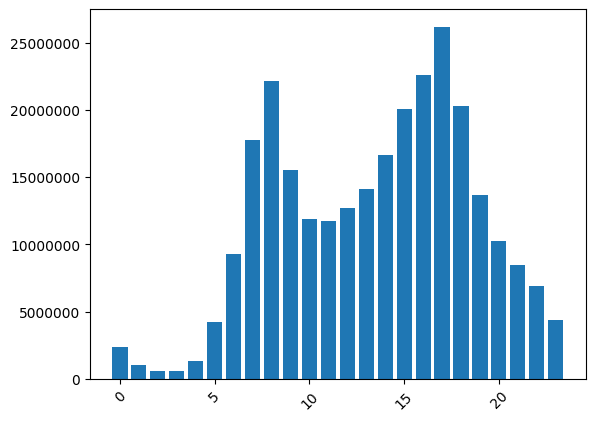

hour of the day: total ridership
0: 2355952.4046
1: 1016291.5595
2: 609685.6535
3: 587057.7875999999
4: 1326038.5767
5: 4238283.6273
6: 9272181.56
7: 17772294.227100004
8: 22146316.1456
9: 15563042.1694
10: 11917519.1109
11: 11710357.1202
12: 12744275.600900002
13: 14148107.2139
14: 16629629.3381
15: 20079622.951
16: 22617136.2058
17: 26183460.9067
18: 20315118.980000004
19: 13689476.827699998
20: 10242757.2407
21: 8457048.3487
22: 6893768.5149
23: 4379941.036


In [7]:
# origin hour of day
hour_of_day = origin['hour_of_day'].unique()
total_ridership_per_hour_of_day = [origin[origin['hour_of_day'] == i]['sum_estimated_average_ridership'].sum() for i in hour_of_day]
plt.bar(hour_of_day, total_ridership_per_hour_of_day)
plt.tick_params(axis='x', labelrotation=45)
plt.ticklabel_format(style='plain')
plt.show()
print('hour of the day: total ridership')
for i in range(len(hour_of_day)):
    print(f'{hour_of_day[i]}: {total_ridership_per_hour_of_day[i]}')

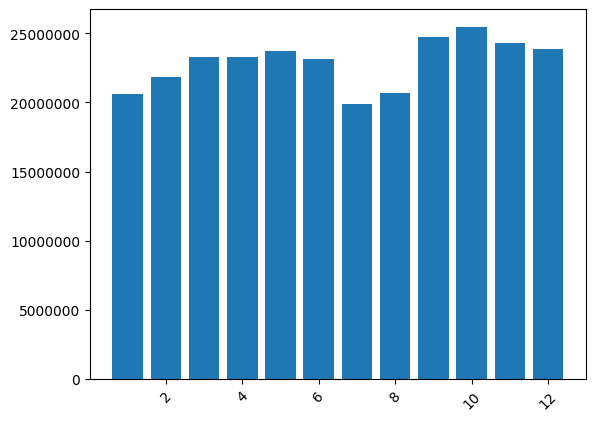

month of the year: total ridership
1: 20640117.3487
2: 21858037.6738
3: 23312621.7179
4: 23260391.0992
5: 23755413.8423
6: 23114608.935900003
7: 19875121.7932
8: 20686265.5928
9: 24742325.3384
10: 25464468.3014
11: 24320913.061899997
12: 23865078.4013


In [8]:
# origin month of year
month = origin['month'].unique()
total_ridership_per_month = [origin[origin['month'] == i]['sum_estimated_average_ridership'].sum() for i in month]
plt.bar(month, total_ridership_per_month)
plt.tick_params(axis='x', labelrotation=45)
plt.ticklabel_format(style='plain')
plt.show()
print('month of the year: total ridership')
for i in range(len(month)):
    print(f'{month[i]}: {total_ridership_per_month[i]}')

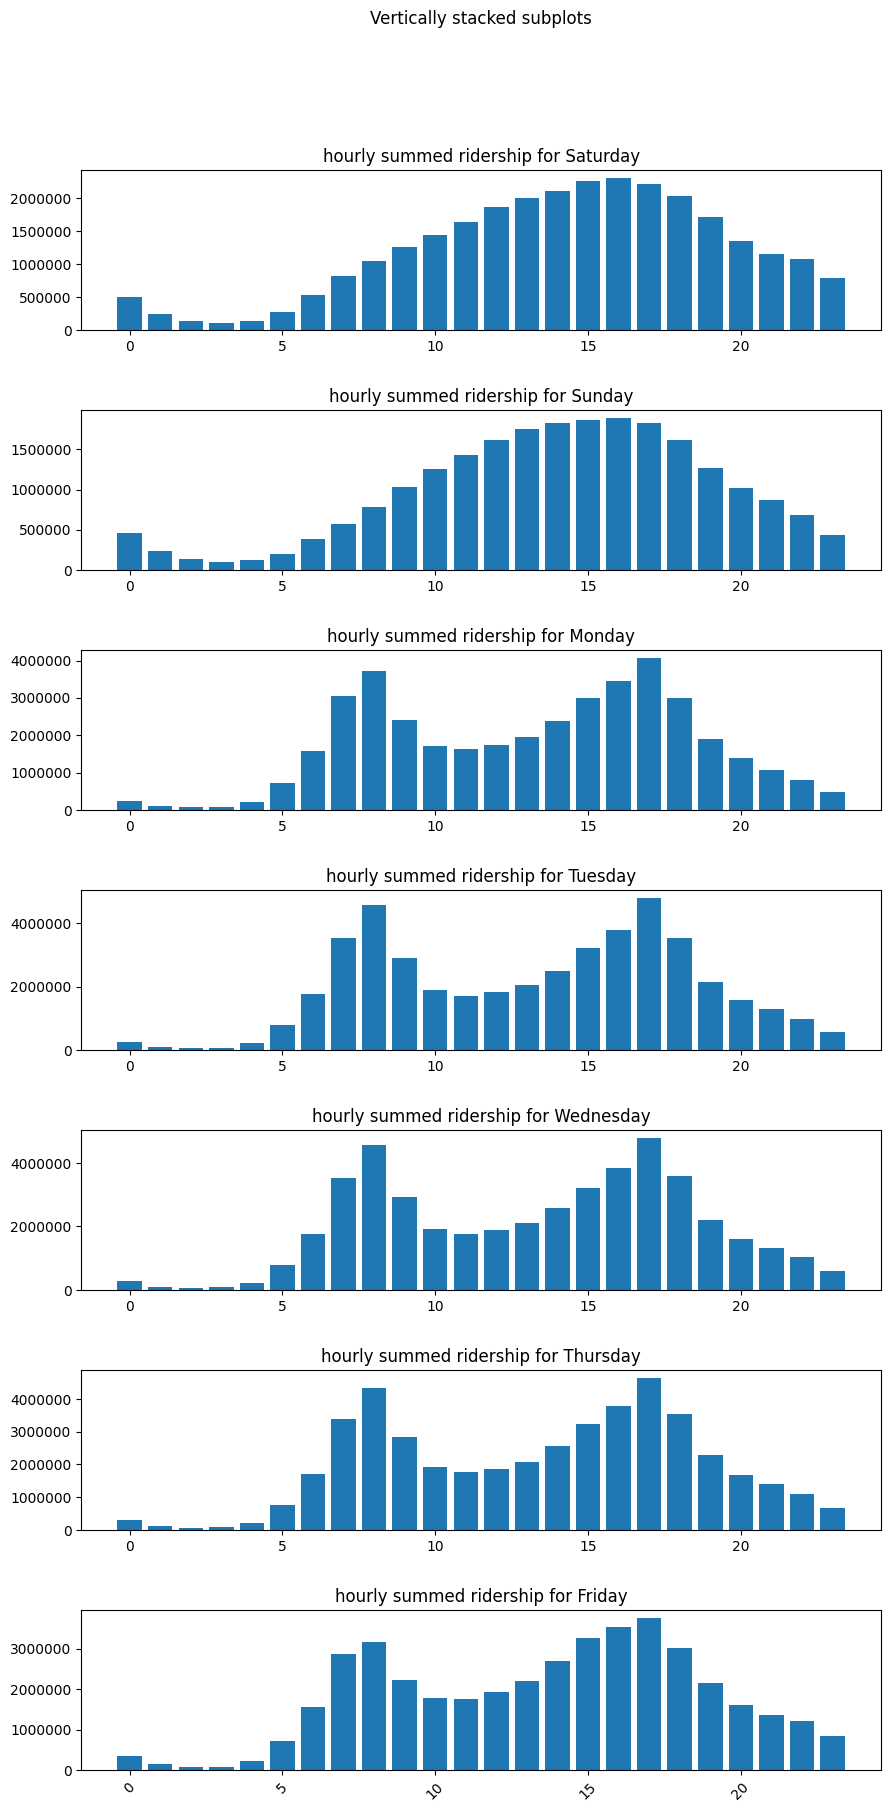

In [18]:
#origin hour of the day by day of the week
day_of_week = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']



fig, axs = plt.subplots(7, figsize = (10,20))
fig.suptitle('Vertically stacked subplots')
fig.subplots_adjust(wspace=0.5, hspace=0.5, top=0.9, bottom=0.1, left=0.1, right=0.9)


for i in range(7):
    daily_dataset = origin[origin['day_of_week'] == day_of_week[i]]
    

    hour_of_day = daily_dataset['hour_of_day'].unique()
    total_ridership_per_hour_of_day = [daily_dataset[daily_dataset['hour_of_day'] == j]['sum_estimated_average_ridership'].sum() for j in hour_of_day]
    axs[i].bar(hour_of_day, total_ridership_per_hour_of_day)
    axs[i].set_title(f'hourly summed ridership for {day_of_week[i]}')
    axs[i].ticklabel_format(style='plain')


plt.tick_params(axis='x', labelrotation=45)

plt.show()


## Maps

### Map of Origin/Destination Routes Weighted by Ridership